#  02. Comprehensive Sensor Physics, Band Visualization & Feature Engineering

This notebook provides a complete remote sensing and machine learning breakdown of multispectral satellite imagery for flood water segmentation:
1. **Sensor Physics & Water Interaction**: Detailed optical physics explaining how each sensor interacts with water surfaces, dissolved organic matter, sediment, and depth.
2. **Individual Band Visualizations**: High-contrast rendering of all 12 bands.
3. **Spectral Composites**: True Color RGB (B3, B2, B1), False Color CIR (B4, B3, B2), and SWIR (B6, B5, B4).
4. **Feature Engineering (Water & Vegetation Indices)**: Formulating and visualizing **MNDWI**, **NDWI**, **AWEI_sh**, and **NDVI**.
5. **The Normalization Methodology**: Scientific explanation of why **image-wise normalization is a critical error** and why **dataset-wise separated channel statistics (from Train only)** is mandatory.

## Section 1: Physical Sensor Interactions with Water Surfaces

| Band Index | Band Name | Central Wavelength | Optical Physics & Water Surface Interaction |
| :---: | :--- | :---: | :--- |
| **B00** | **Coastal Aerosol** | 0.44 µm | **High water penetration & atmospheric scattering**. Shortest optical wavelength; penetrates shallow coastal/river waters to map bathymetry. Extremely sensitive to atmospheric Rayleigh scattering and thin cirrus. |
| **B01** | **Blue** | 0.49 µm | **Deep water penetration**. Light in this band penetrates up to 20–30 meters in clear water. Absorbed by Colored Dissolved Organic Matter (CDOM) and chlorophyll. Clear water appears relatively bright compared to longer wavelengths. |
| **B02** | **Green** | 0.56 µm | **Water reflectance peak**. Pure water has its lowest absorption in the blue-green spectrum. This band provides the positive numerator for classical water indices (**NDWI** & **MNDWI**). Submerged vegetation shows moderate reflectance here. |
| **B03** | **Red** | 0.66 µm | **Turbidity & Sediment Sensitivity**. Pure water starts absorbing red light significantly. However, in flood conditions, water carries heavy suspended sediment, clay, and mud, creating a strong backscattering peak in Red. Differentiates turbid floodwaters from clear lakes. |
| **B04** | **Near-Infrared (NIR)** | 0.86 µm | **Total Water Absorption & Vegetation Contrast**. Water absorbs almost 100% of incident NIR energy (appears pitch black when clean). Conversely, living vegetation reflects 50–60% of NIR due to spongy mesophyll leaf structure. This sharp contrast creates the water-land boundary. |
| **B05** | **SWIR 1** | 1.61 µm | **Built-Up vs. Water Separation**. Water completely absorbs SWIR1 radiation. Crucially, dry soil and urban concrete/asphalt reflect strongly in SWIR1. Using SWIR1 instead of NIR eliminates the classic false-positive water classifications in built-up cities (**MNDWI**). |
| **B06** | **SWIR 2** | 2.20 µm | **Soil Moisture & Saturated Mud**. Highly sensitive to hydroxyl bonds and water content in soils. Allows the model to distinguish shallow standing floodwaters from merely damp/saturated muddy fields. |
| **B07** | **QA Band** | Bitmask | **Quality Assurance Flags**. Categorical bit flags indicating cloud cover, cloud shadows, snow/ice, and aerosol optical depth to prevent false water classifications caused by dark cloud shadows. |
| **B08** | **Merit DEM** | Elevation (m) | **Hydro-conditioned Topography**. Digital elevation model processed to remove vegetation canopy bias, highlighting river valleys and flood-prone drainage sinks (contains fill value -9999). |
| **B09** | **Copernicus DEM** | Elevation (m) | **30m Global Surface Elevation**. Seamless digital surface model providing ground elevation to model gravitational water accumulation (water only flows downhill and pools in depressions). |
| **B10** | **ESA WorldCover** | Land Class | **Categorical Land Cover Prior**. 10m global land cover (Cropland, Forest, Grassland, Built-up, Permanent Water) providing prior context for seasonal vs floodwater discrimination. |
| **B11** | **Water Occurrence** | Probability % | **Historical Occurrence Prior**. Long-term historical water presence probability (0-100%). High correlation with permanent water bodies, helping separate episodic flood surges from permanent lakes. |

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

for candidate in [Path.cwd(), Path.cwd().parent, Path('e:/Cellula_Technologies/Project2/water_segmentation')]:
    if (candidate / 'data' / 'raw' / 'images').exists() and (candidate / 'src').exists():
        project_root = candidate
        break
    elif (candidate / 'water_segmentation' / 'data' / 'raw' / 'images').exists():
        project_root = candidate / 'water_segmentation'
        break
else:
    project_root = Path('e:/Cellula_Technologies/Project2/water_segmentation')

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import tifffile
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

from src.utils.paths import get_data_dirs, resolve_file
from src.data.feature_engineering import compute_mndwi, compute_ndwi, compute_awei_sh, compute_ndvi
from src.utils.visualization import create_rgb_composite


##  Section 2: Load Sample Scene & Visualize All 12 Bands

Loaded Scene 0: Image shape (128, 128, 12), Mask shape (128, 128)
Water percentage: 11.70%


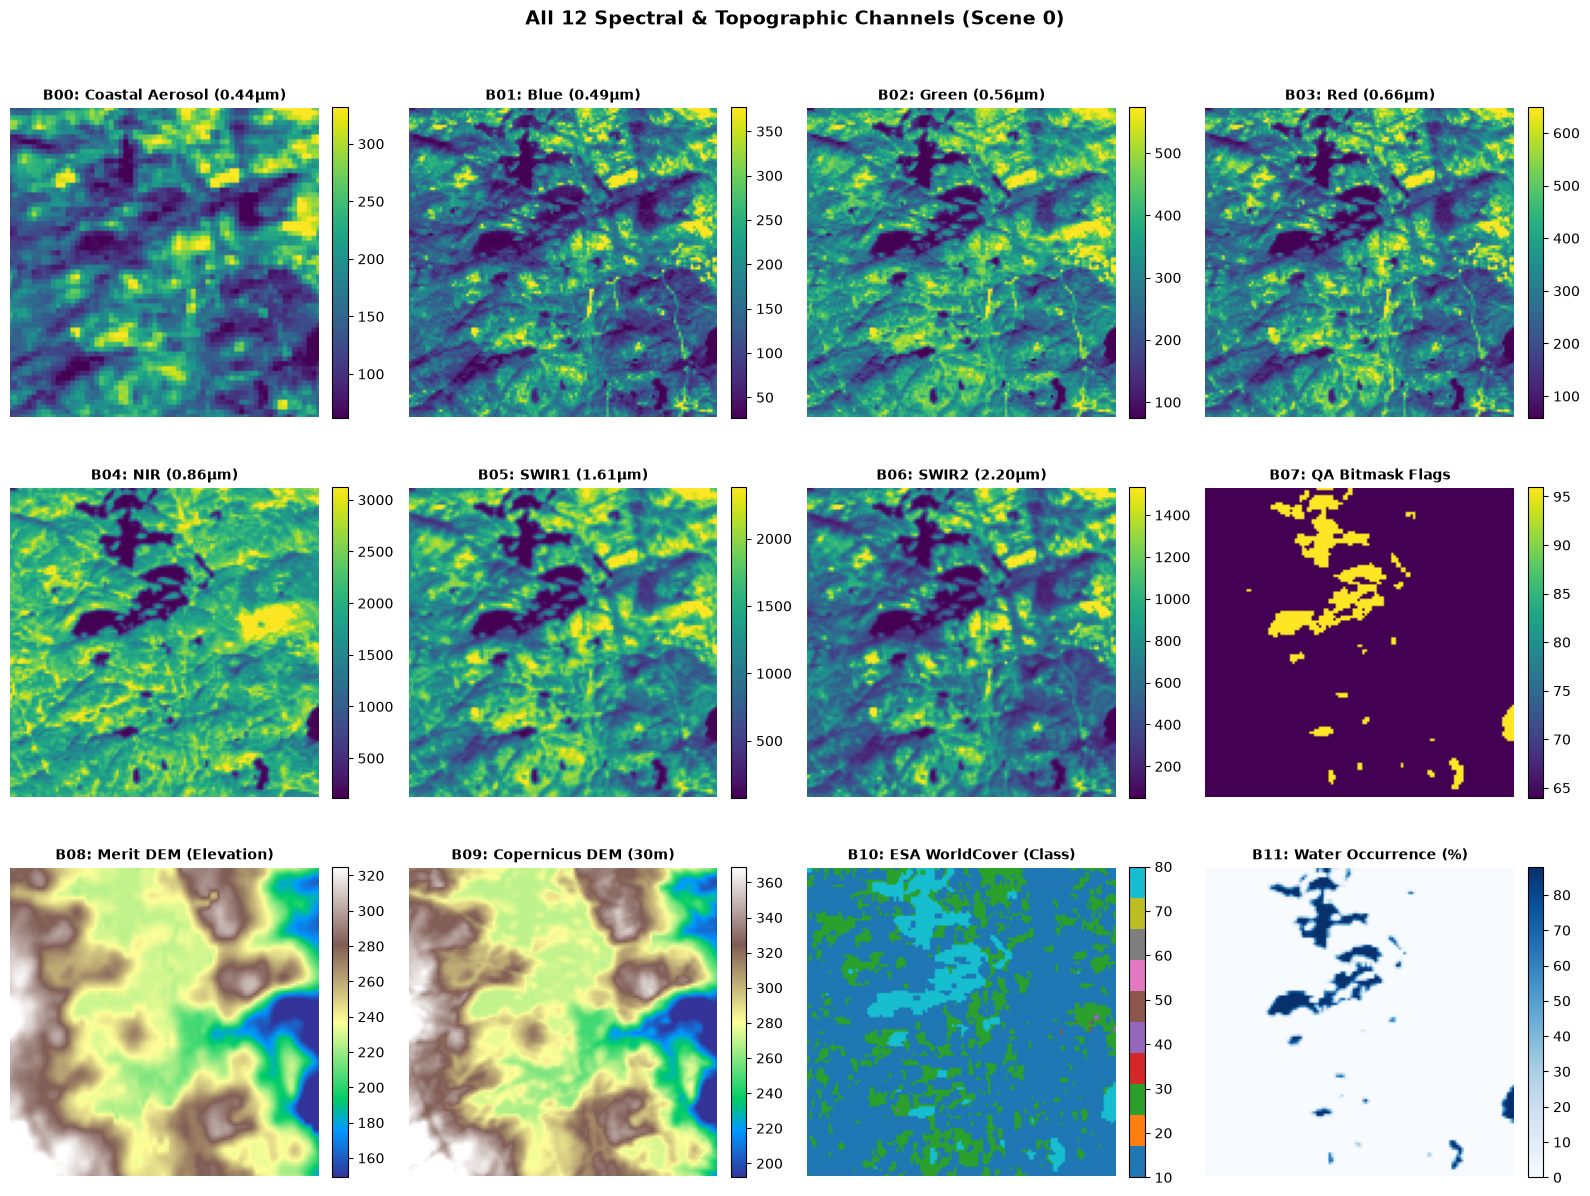

In [2]:
img_dir, lbl_dir, splits_dir, stats_dir, checkpoints_dir = get_data_dirs()

sample_id = 0
raw_img = tifffile.imread(str(img_dir / f"{sample_id}.tif"))
mask = np.array(Image.open(str(lbl_dir / f"{sample_id}.png")))

print(f"Loaded Scene {sample_id}: Image shape {raw_img.shape}, Mask shape {mask.shape}")
print(f"Water percentage: {(mask == 1).mean():.2%}")

band_titles = [
    "B00: Coastal Aerosol (0.44µm)", "B01: Blue (0.49µm)", "B02: Green (0.56µm)", "B03: Red (0.66µm)",
    "B04: NIR (0.86µm)", "B05: SWIR1 (1.61µm)", "B06: SWIR2 (2.20µm)", "B07: QA Bitmask Flags",
    "B08: Merit DEM (Elevation)", "B09: Copernicus DEM (30m)", "B10: ESA WorldCover (Class)", "B11: Water Occurrence (%)"
]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for b in range(12):
    ax = axes[b // 4, b % 4]
    b_data = raw_img[:, :, b].astype(float)
    if b == 8:
        valid = b_data[b_data != -9999]
        vmin, vmax = (np.percentile(valid, 2), np.percentile(valid, 98)) if len(valid) > 0 else (0, 1)
    else:
        vmin, vmax = np.percentile(b_data, 2), np.percentile(b_data, 98)
        
    cmap = "terrain" if b in [8, 9] else ("Blues" if b == 11 else ("tab10" if b == 10 else "viridis"))
    im = ax.imshow(b_data, vmin=vmin, vmax=vmax, cmap=cmap)
    ax.set_title(band_titles[b], fontsize=10, fontweight="bold")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f"All 12 Spectral & Topographic Channels (Scene {sample_id})", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


##  Section 3: Spectral Composites (True Color RGB, False Color CIR, SWIR)

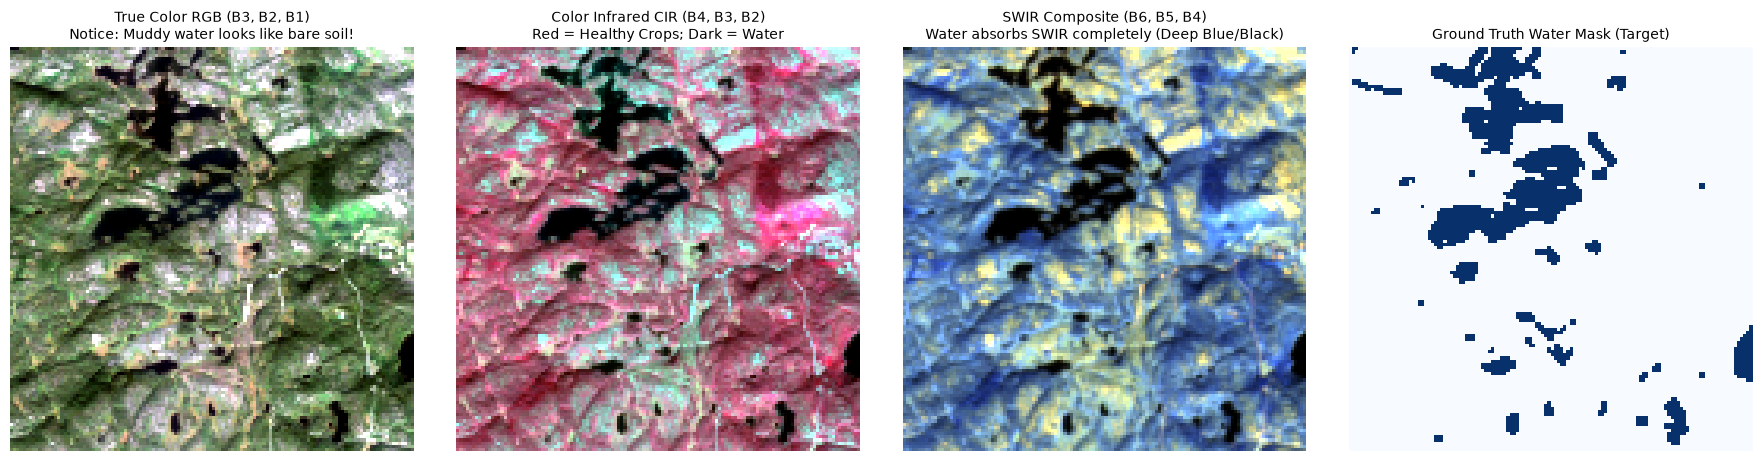

In [3]:
raw_chw = np.transpose(raw_img, (2, 0, 1))

rgb_true = create_rgb_composite(raw_chw, r_idx=3, g_idx=2, b_idx=1)  # Red, Green, Blue
rgb_cir  = create_rgb_composite(raw_chw, r_idx=4, g_idx=3, b_idx=2)  # NIR, Red, Green
rgb_swir = create_rgb_composite(raw_chw, r_idx=6, g_idx=5, b_idx=4)  # SWIR2, SWIR1, NIR

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
axes[0].imshow(rgb_true)
axes[0].set_title("True Color RGB (B3, B2, B1)\nNotice: Muddy water looks like bare soil!", fontsize=10)
axes[0].axis("off")

axes[1].imshow(rgb_cir)
axes[1].set_title("Color Infrared CIR (B4, B3, B2)\nRed = Healthy Crops; Dark = Water", fontsize=10)
axes[1].axis("off")

axes[2].imshow(rgb_swir)
axes[2].set_title("SWIR Composite (B6, B5, B4)\nWater absorbs SWIR completely (Deep Blue/Black)", fontsize=10)
axes[2].axis("off")

axes[3].imshow(mask, cmap="Blues")
axes[3].set_title("Ground Truth Water Mask (Target)", fontsize=10)
axes[3].axis("off")

plt.tight_layout()
plt.show()

##  Section 4: Domain-Specific Feature Engineering (Water Indices)

Rather than blindly passing raw channels, we engineer mathematically grounded remote sensing indices:
1. **MNDWI** (Xu, 2006): $\frac{\text{Green} - \text{SWIR1}}{\text{Green} + \text{SWIR1}}$ — Replaces NIR with SWIR1 to suppress false alarms from urban concrete/soil.
2. **NDWI** (McFeeters, 1996): $\frac{\text{Green} - \text{NIR}}{\text{Green} + \text{NIR}}$ — Classical water body delineator maximizing water and minimizing terrestrial reflectance.
3. **AWEI_sh** (Feyisa et al., 2014): $\text{Blue} + 2.5 \times \text{Green} - 1.5 \times (\text{NIR} + \text{SWIR1}) - 0.25 \times \text{SWIR2}$ — Specially formulated with positive coefficients on visible bands to eliminate mountain and cloud shadow false positives.
4. **NDVI** (Rouse et al., 1974): $\frac{\text{NIR} - \text{Red}}{\text{NIR} + \text{Red}}$ — Differentiates vegetative canopies and flooded croplands from open water surfaces.

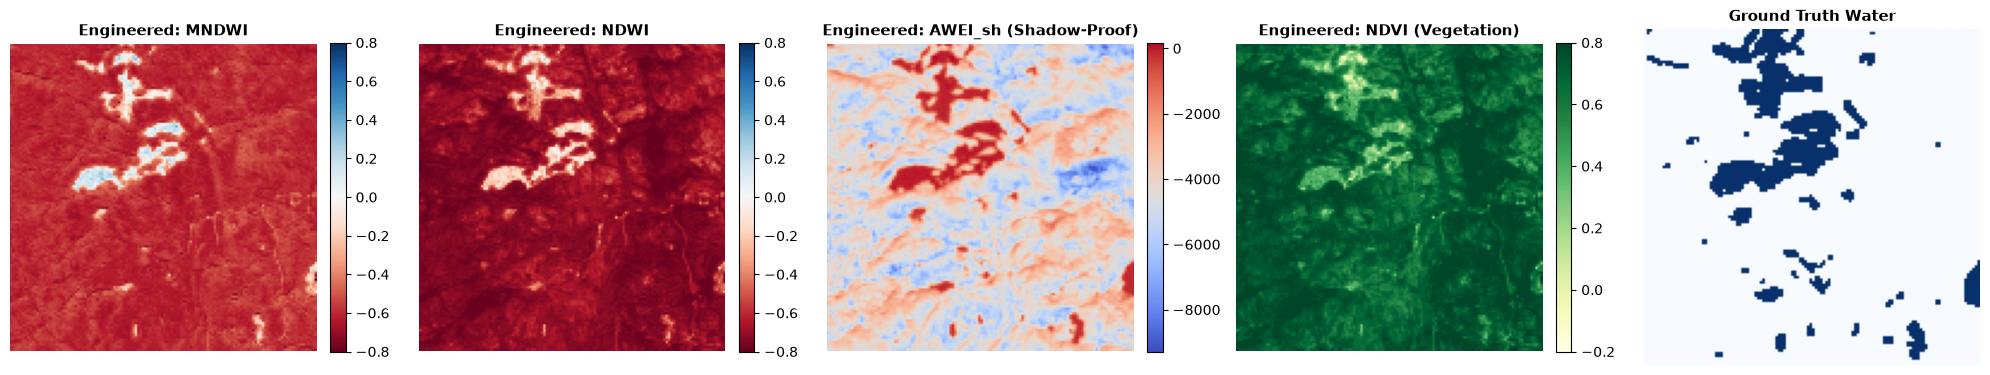

In [4]:
green = raw_img[:, :, 2]
red   = raw_img[:, :, 3]
blue  = raw_img[:, :, 1]
nir   = raw_img[:, :, 4]
swir1 = raw_img[:, :, 5]
swir2 = raw_img[:, :, 6]

feat_mndwi   = compute_mndwi(green, swir1)
feat_ndwi    = compute_ndwi(green, nir)
feat_awei_sh = compute_awei_sh(blue, green, nir, swir1, swir2)
feat_ndvi    = compute_ndvi(nir, red)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

im0 = axes[0].imshow(feat_mndwi, cmap="RdBu", vmin=-0.8, vmax=0.8)
axes[0].set_title("Engineered: MNDWI", fontsize=11, fontweight="bold")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(feat_ndwi, cmap="RdBu", vmin=-0.8, vmax=0.8)
axes[1].set_title("Engineered: NDWI", fontsize=11, fontweight="bold")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(feat_awei_sh, cmap="coolwarm")
axes[2].set_title("Engineered: AWEI_sh (Shadow-Proof)", fontsize=11, fontweight="bold")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

im3 = axes[3].imshow(feat_ndvi, cmap="YlGn", vmin=-0.2, vmax=0.8)
axes[3].set_title("Engineered: NDVI (Vegetation)", fontsize=11, fontweight="bold")
axes[3].axis("off")
plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

axes[4].imshow(mask, cmap="Blues")
axes[4].set_title("Ground Truth Water", fontsize=11, fontweight="bold")
axes[4].axis("off")

plt.tight_layout()
plt.show()

##  Section 5: Normalization — Image-Wise vs. Dataset-Wise (Separated Channels)

###  Why Image-Wise Normalization is a Grave Error:
- If you normalize an image individually: `(img - img.min()) / (img.max() - img.min())` or `(img - img.mean()) / img.std()`:
  1. **Destroys Absolute Physical Reflectance**: A completely dry, arid desert scene with no water will have its darkest pixel mapped to 0.0 and brightest to 1.0. A scene covered 100% in floodwater will also have its pixels mapped from 0.0 to 1.0! The network loses the ability to discern whether a pixel is truly water or just the darkest rock in a desert.
  2. **Inter-Scene Comparison Breakdown**: Different acquisition dates or cloud conditions will distort relative radiance thresholds.

###  The Correct Approach: Dataset-Wise (Per-Channel Separated Statistics):
1. Compute statistics **STRICTLY on the Training Split** across all training scenes:
   - Compute per-channel separate Min and Max: $\text{Min}_c, \text{Max}_c$
   - Or per-channel separate Mean and Standard Deviation: $\mu_c, \sigma_c$
2. Freeze these statistics and apply them identically to Validation and Test scenes.
3. This preserves physical radiometric calibration and prevents data leakage.

In [5]:
stats_file = resolve_file("data/statistics/engineered_train_stats.json")
with open(stats_file, "r") as f:
    eng_stats = json.load(f)

df_eng_stats = pd.DataFrame({
    "Feature Name": eng_stats.get("feature_names", eng_stats.get("channel_names")),
    "Train Mean": [f"{m:+.4f}" for m in eng_stats["means"]],
    "Train Std": [f"{s:.4f}" for s in eng_stats["stds"]],
    "Min (1st perc)": [f"{mn:+.4f}" for mn in eng_stats["mins"]],
    "Max (99th perc)": [f"{mx:+.4f}" for mx in eng_stats["maxs"]],
})
display(df_eng_stats)


,Feature Name,Train Mean,Train Std,Min (1st perc),Max (99th perc)
0,coastal_aerosol,+416.9688,263.6013,-1393.0000,+6568.0000
1,blue,+516.1412,314.2422,-846.0000,+9659.0000
2,green,+857.6532,400.2589,-181.0000,+11368.0000
3,red,+1036.5318,566.9232,-318.0000,+12041.0000
4,nir,+2121.3004,1062.1136,-412.0000,+15841.0000
5,swir1,+2044.1742,1242.7855,-335.0000,+15252.0000
6,swir2,+1413.6869,1001.6111,-258.0000,+14647.0000
7,copernicus_dem,+284.1222,426.6109,+10.0000,+2762.0000
8,mndwi,-0.2669,0.4946,-1.0000,+1.0000
9,ndwi,-0.3435,0.3443,-1.0000,+1.0000
